The PyTorch workflow is the process of creating and refining a model. In general, it contains the following steps:
1. Preparing and loading the data
2. Building the model
3. Fitting the model to the data (training)
4. Making predictions and evaluating a model
5. Saving and loading a model

In [1]:
import torch as t
from torch import nn    #PyTorch's module for neural networks
import torch.optim as optim
import matplotlib.pyplot as plt     #For visualization of the AI's data

Machine learning consists of two parts:
- getting data into a numerical format
- building a model that learns from that numerical data

A *"simple"* way to do this is by using the linear regression formula.

y = X*b + a
where b is the weight, a is the bias and X is a matrix or tensor.

In [2]:
#*known* parameters
weight = 0.7    #the "slope"
bias = 0.3      #the "x-intercept"

start = 0
end = 1
step = 0.02
X = t.arange(start, end, step).unsqueeze(1)
y = weight * X + bias

print(X[:10], "\n", y[:10])
print(len(X), len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 
 tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
50 50


An important part of building AI models is *splitting Data sets into training and test data*. The training Data is the data the model trains on, which is the bigger part. The test data is the part of the data that the model ***doesn't see*** until it's being tested.

In [3]:
train_split = int(len(X)*0.8)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

40 40
10 10


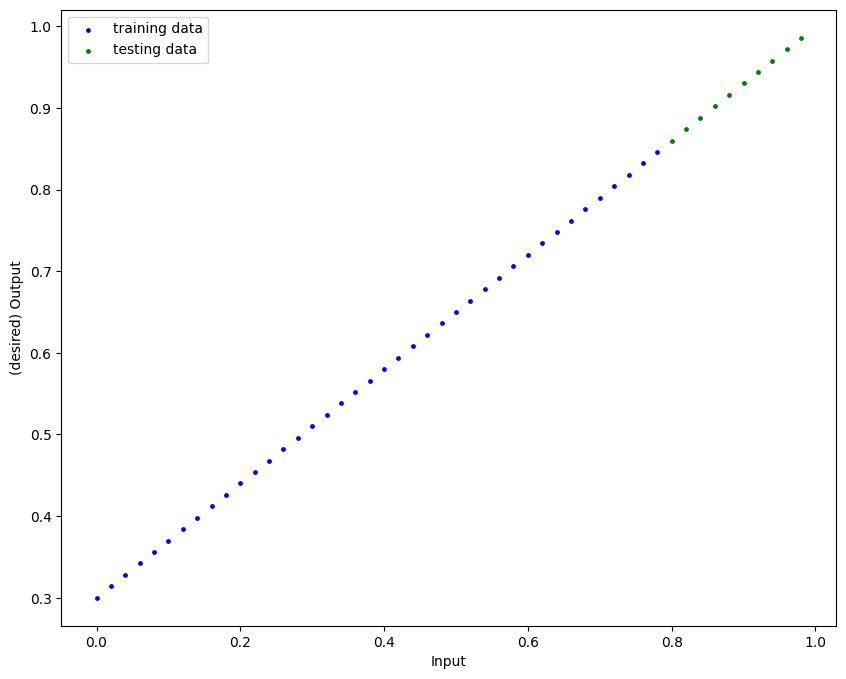

In [4]:
def plotData(training_data=X_train,
             training_label=y_train,
             testing_data=X_test,
             testing_label=y_test,
             predictions=None):
    plt.figure(0, figsize=(10, 8))
    plt.xlabel('Input')
    plt.ylabel('(desired) Output')

    plt.scatter(training_data, training_label, c='b', label='training data', s=6)

    plt.scatter(testing_data, testing_label, color='g', label='testing data', s=6)

    if predictions is not None:
        plt.scatter(testing_data, predictions, color='r', label='predictions', s=6)

    plt.legend(prop={'size': 10})

plotData();

To build models, I'll be using classes, so learning them will be a new TODO :P

What the model will do:
- start with random values for weight and bias
- adjust those values to better represent the training data

How does it do that?
With 2 main algorithms:
+ **gradient descent**
+ **Backpropagation**

In [5]:
from torch import nn

#linear regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(t.randn(1,                  #<-- starting with random parameters and try to adjust it to the ideal value later
                                            requires_grad=True, #<-- can this value be updated via gradient descent?
                                            dtype=t.float))     #<-- pyTorch's "favourite" default datatype
        self.bias = nn.Parameter(t.randn(1,
                                         requires_grad=True,
                                         dtype=t.float))

    def forward(self, x: t.Tensor) -> t.Tensor:
        return self.weights * x + self.bias     #The linear regression formular from before


**important classes for the future**
- torch.nn - contains all the *"building blocks"* for neural networks (/**computational graphs**)
- torch.nn.Module - the superclass for all PyTorch neural networks; forward() should be ***overridden*** when you subclass it
- torch.nn.Parameter - the parameters that the model should try and improve; oftentimes instantiated ***automatically***
- torch.optim - the PyTorch optimizer; helps with **gradient descent**
- torch.utils.Dataset - for more complicated Datasets; a map between **label** (key) and **data**
- torch.utils.data.Dataloader - Creates an **iterable** over Data

A compilation of all important parts: https://pytorch-cn.com/tutorials/beginner/ptcheat.html

Let's check out our model!

The models parameters/what's inside can be accessed with **.parameters()**

In [6]:
#creating a random seed
t.manual_seed(42)

#creating an instance of the model
model = LinearRegressionModel()

#looking at the parameters
print(list(model.parameters()))

#list named parameters
print(model.state_dict())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


##  Making predictions with torch.inference_mode():
To check the models predictive power, we can test how well it predicts y_test based on X_test.

When data is passed through this model, the forward() method is used.

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])
OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


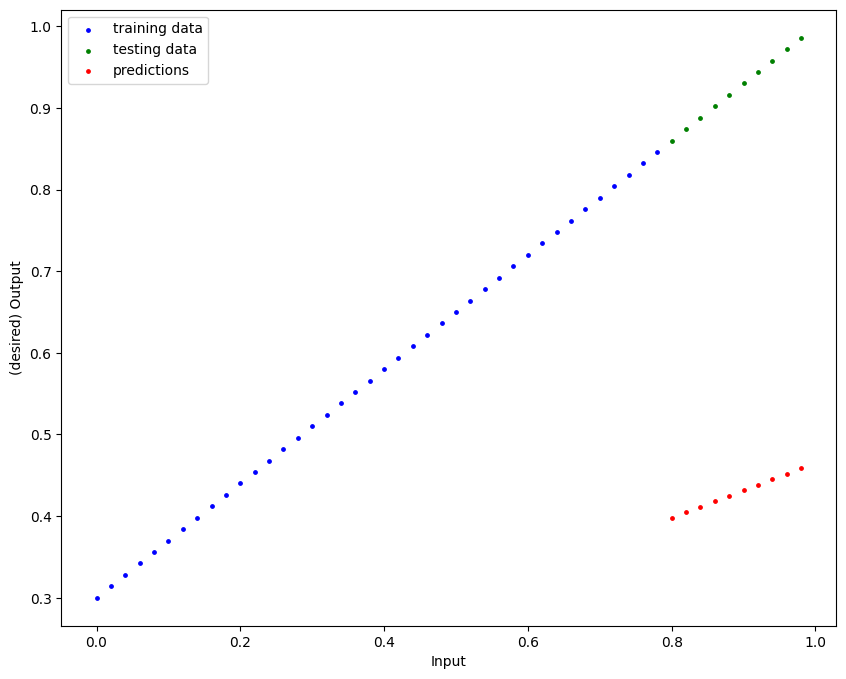

In [7]:
with t.inference_mode():
    y_pred = model(X_test)

print(y_pred)
plotData(predictions=y_pred)
print(model.state_dict())

In [8]:
y_pred_noInferenceMode = model(X_test)
print(y_pred_noInferenceMode)

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)


When using **inference mode**, PyTorch doesn't automatically use some default *grad function*. This is useful for **testing** models and should be a habit to keep for later on, as it reduces the amount of data that pyTorch has to keep track of behind the scenes. For a dataset this small, it doesn't make a difference. For larger models however it will be useful to get predictions faster.
***
Torch.no_grad() does something similar to inference mode, but it's the older and deprecated method of doing so.



## Training a model

The idea of training a model is for it to move from some *unknown* parameters, which may be random, to some *known* parameters.

This means that it should go from a poor representation of the data to a better one.

One way to measure the quality of the models predictions is by using a **loss function** (aka **cost function** or **criterion**).

**Things we need to train:**
- **Loss function**: to measure the quality of the predictions; Lower values are better
- **Optimizer**: to adjust the models parameters based on the loss functions result (e.g. weight, bias)

**Specifically for PyTorch**, we also need:
- A **training loop**
- A **testing loop**

More info about loss functions: https://docs.pytorch.org/docs/stable/nn.html#loss-functions

In [9]:
#Setting up a loss function
loss_fn = t.nn.L1Loss()

#Setting up an optimizer (in this case stochastic gradient descent)
optimizer = t.optim.SGD(params=model.parameters(),
                        lr=0.01) # learning rate: possibly the most important hyperparameter you can set

The optimizer takes in 2 parameters:
- The parameters of the model which it should adjust
- The **learning rate**, which defines how big or small the optimizers changes should be with each small step

## Building a training loop

There are multiple things you need in a training loop:

0. Loop through the data and do the following steps:
1. Forward pass (data moving through the .forward() function to make predictions (aka forward propagation)
2. Calculating the loss
3. Optimizer zero grad (explaination will come later)
4. Loss backward - move backwards through the model to calculate the gradient of the parameters based on the previously calculated loss (**backpropagation** - implemented by PyTorch)
5. Optimizer step - use the optimizer to adjust the model's parameters with the goal of minimizing the loss (**gradient descent** - implemented by PyTorch)

tensor(0.1170, grad_fn=<MeanBackward0>)


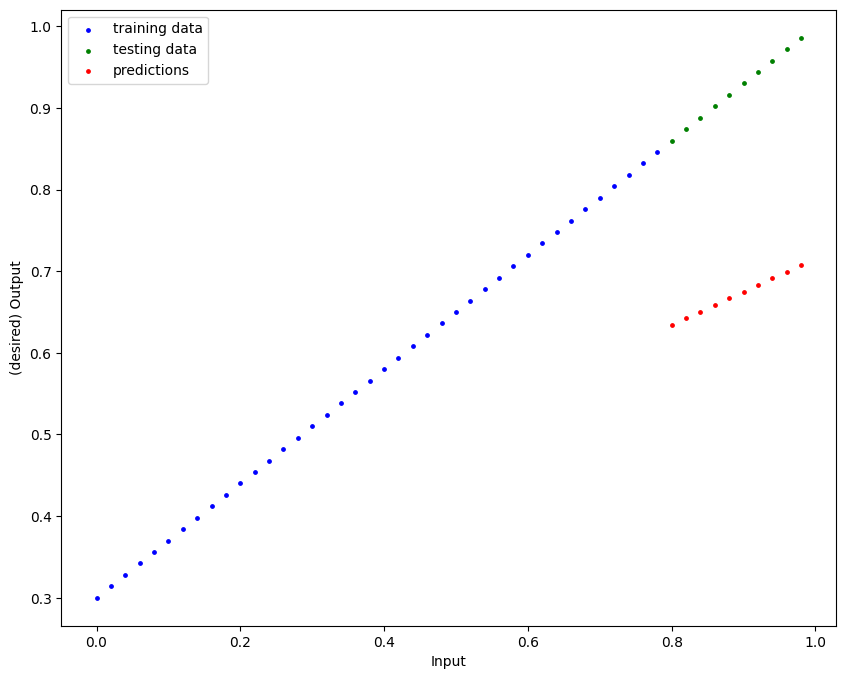

In [27]:
epochs = 1
#an epoch is one loop through the data (a hyperparameter as we can set it ourselves)

for epoch in range(epochs):
    #Set the model to training mode
    model.train()
    #Training mode sets all parameters that require gradients to require gradients

    #1. Forward pass
    y_pred = model(X_train)

    #2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    print(loss)

    #3. Optimizer zero grad
    optimizer.zero_grad()


    #4. Execute backpropagation on the loss with respect to the models parameters
    loss.backward()

    #5. Step the optimizer
    optimizer.step() #by default, how the optimizer steps will accumulate through the loop, therefore we have to zero it for the next iteration of the loop in step 3


model.eval() #Turns off gradient tracking (for evaluation)
with t.inference_mode():
    trainedPredictions = model(X_test)
    plotData(predictions=trainedPredictions)